# EE 541 Homework 9 — Transfer learning (burning liquids)

**Goal:** Fine-tune pretrained `ResNet-34` with staged unfreezing, report metrics, confusion matrix, precision–recall, and convolutional feature visualizations.


In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet34_Weights
from torchvision.utils import make_grid
from tqdm.auto import tqdm

HW9_ROOT = Path.cwd().resolve()
if not (HW9_ROOT / "prepared_data").is_dir():
    cand = HW9_ROOT / "HW9"
    if (cand / "prepared_data").is_dir():
        HW9_ROOT = cand
    else:
        raise FileNotFoundError("prepared_data/ not found — run prepare_data.py from HW9 first")

os.chdir(HW9_ROOT)
print("HW9_ROOT =", HW9_ROOT)
if (HW9_ROOT / "data").is_dir():
    print("Flat data/ layout present:", sorted(p.name for p in (HW9_ROOT / "data").iterdir() if p.is_dir()))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
torch.manual_seed(541)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(541)


HW9_ROOT = /scratch/faculty/hkim/quanhao/EE541/HW9
Flat data/ layout present: ['ethanol', 'pentane', 'propanol']
device: cpu


## 1. Data layout and loaders

Per the assignment: **Supplementary File #2** images live under `S1_Raw_Photographs_Full_Study/`. Running `prepare_data.py` creates (1) a flat **`data/{ethanol,pentane,propanol}/`** tree for `ImageFolder`, and (2) **`prepared_data/{train,val,test}/...`** with a **70% / 15% / 15%** stratified split per class (seed **42**), which is appropriate for **N≈3000** images (enough train data while keeping held-out val/test). Loaders below use the split folders. **224×224** inputs, ImageNet **normalize**, **ColorJitter** for contrast/intensity, plus flip / rotation / random crop **augmentation** on train only.

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_tf = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.25, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)
eval_tf = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

train_dir = HW9_ROOT / "prepared_data" / "train"
val_dir = HW9_ROOT / "prepared_data" / "val"
test_dir = HW9_ROOT / "prepared_data" / "test"

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds = datasets.ImageFolder(val_dir, transform=eval_tf)
test_ds = datasets.ImageFolder(test_dir, transform=eval_tf)
class_names = train_ds.classes
idx_to_name = {i: n for i, n in enumerate(class_names)}
print("classes:", class_names, "counts train:", [sum(1 for _, y in train_ds.samples if y == i) for i in range(len(class_names))])

BATCH = 32 if device.type == "cuda" else 16
NW = 0 

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NW, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NW, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NW, pin_memory=(device.type == "cuda"))
len(train_ds), len(val_ds), len(test_ds)


classes: ['ethanol', 'pentane', 'propanol'] counts train: [700, 700, 700]


(2100, 450, 450)

## 2. Model helpers

Pretrained `ResNet-34` (`IMAGENET1K_V1`), replace `fc` for three classes. Staged training: start with backbone frozen; then unfreeze `layer4` with a smaller learning rate.

In [3]:
def build_model(num_classes: int = 3) -> nn.Module:
    weights = ResNet34_Weights.IMAGENET1K_V1
    m = models.resnet34(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)


def set_trainable(model: nn.Module, mode: str) -> None:
    for p in model.parameters():
        p.requires_grad = False
    if mode == "fc_only":
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "fc_layer4":
        for p in model.fc.parameters():
            p.requires_grad = True
        for p in model.layer4.parameters():
            p.requires_grad = True
    elif mode == "fc_layer3_layer4":
        for p in model.fc.parameters():
            p.requires_grad = True
        for p in model.layer3.parameters():
            p.requires_grad = True
        for p in model.layer4.parameters():
            p.requires_grad = True
    else:
        raise ValueError(mode)


def count_trainable(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion) -> tuple[float, float]:
    model.eval()
    tot_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        tot_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        n += xb.size(0)
    return tot_loss / max(n, 1), correct / max(n, 1)


def train_one_epoch(model: nn.Module, loader: DataLoader, criterion, optimizer) -> tuple[float, float]:
    model.train()
    tot_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        tot_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        n += xb.size(0)
    return tot_loss / max(n, 1), correct / max(n, 1)


## 3. Fine-tuning with staged unfreezing

Phase A: only `fc`, Adam `lr=1e-4`. Phase B: `fc` + `layer4`, `lr=1e-5`. Phase C (optional refinement): add `layer3`, same small LR. Vertical markers on plots correspond to phase boundaries.

In [4]:
criterion = nn.CrossEntropyLoss()

model_ft = build_model(num_classes=len(class_names))
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "phase": [],
    "lr": [],
    "trainable_params": [],
}

phases = [
    {"name": "fc_only", "trainable": "fc_only", "epochs": 4, "lr": 1e-4},
    {"name": "fc+layer4", "trainable": "fc_layer4", "epochs": 4, "lr": 1e-5},
    {"name": "fc+layer3+layer4", "trainable": "fc_layer3_layer4", "epochs": 3, "lr": 5e-6},
]

epoch_id = 0
for ph in phases:
    set_trainable(model_ft, ph["trainable"])
    params = [p for p in model_ft.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=ph["lr"])
    print(f"\n=== Phase {ph['name']}: lr={ph['lr']}, trainable tensors={count_trainable(model_ft):,} ===")
    for _ in range(ph["epochs"]):
        epoch_id += 1
        tr_loss, tr_acc = train_one_epoch(model_ft, train_loader, criterion, opt)
        va_loss, va_acc = evaluate(model_ft, val_loader, criterion)
        history["epoch"].append(epoch_id)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["phase"].append(ph["name"])
        history["lr"].append(ph["lr"])
        history["trainable_params"].append(count_trainable(model_ft))
        print(
            f"epoch {epoch_id:02d}  train loss {tr_loss:.4f} acc {tr_acc:.4f}  |  val loss {va_loss:.4f} acc {va_acc:.4f}"
        )



=== Phase fc_only: lr=0.0001, trainable tensors=1,539 ===


epoch 01  train loss 1.0611 acc 0.4310  |  val loss 1.0009 acc 0.5133


epoch 02  train loss 0.9228 acc 0.5881  |  val loss 0.8735 acc 0.6244


epoch 03  train loss 0.8392 acc 0.6433  |  val loss 0.7980 acc 0.6911


epoch 04  train loss 0.7734 acc 0.6938  |  val loss 0.7464 acc 0.7156

=== Phase fc+layer4: lr=1e-05, trainable tensors=13,115,907 ===


...

epoch 07  train loss 0.3402 acc 0.8695  |  val loss 0.2776 acc 0.9022


epoch 08  train loss 0.3444 acc 0.8686  |  val loss 0.2395 acc 0.9333

=== Phase fc+layer3+layer4: lr=5e-06, trainable tensors=19,938,307 ===


epoch 09  train loss 0.2891 acc 0.8867  |  val loss 0.2445 acc 0.9133


epoch 10  train loss 0.2804 acc 0.8833  |  val loss 0.1649 acc 0.9511


epoch 11  train loss 0.2494 acc 0.9024  |  val loss 0.1583 acc 0.9489


## 4. Learning curves (annotated at phase changes)

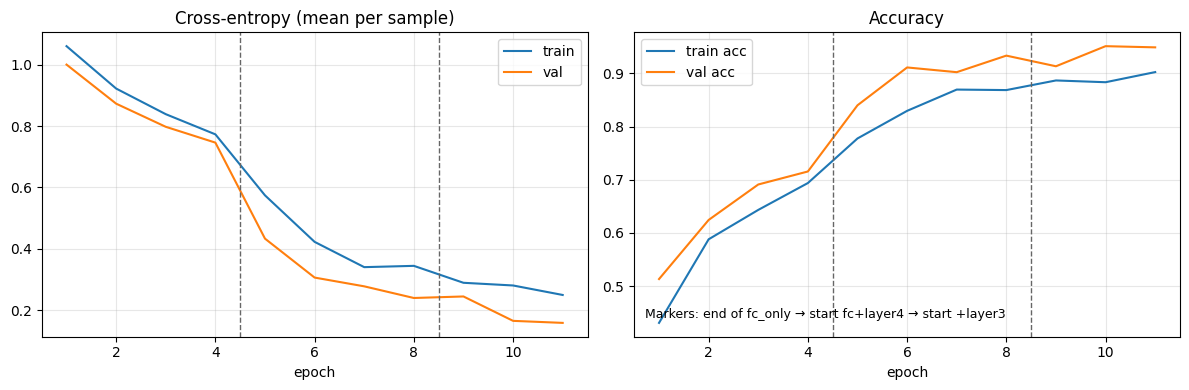

saved /scratch/faculty/hkim/quanhao/EE541/HW9/hw9_learning_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = np.array(history["epoch"])

axes[0].plot(ep, history["train_loss"], label="train")
axes[0].plot(ep, history["val_loss"], label="val")
axes[0].set_title("Cross-entropy (mean per sample)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["train_acc"], label="train acc")
axes[1].plot(ep, history["val_acc"], label="val acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

boundaries = []
acc_phases = list(dict.fromkeys(history["phase"]))
running = 0
for ph in phases:
    running += ph["epochs"]
    boundaries.append(running)

for b in boundaries[:-1]:
    for ax in axes:
        ax.axvline(b + 0.5, color="0.4", ls="--", lw=1)
axes[1].text(0.02, 0.06, "Markers: end of fc_only → start fc+layer4 → start +layer3", transform=axes[1].transAxes, fontsize=9)

plt.tight_layout()
fig_path = HW9_ROOT / "hw9_learning_curves.png"
plt.savefig(fig_path, dpi=160)
plt.show()
print("saved", fig_path)


## 5. Test accuracy — fine-tuned vs baseline

**Baseline (vanilla pretrained ResNet-34 on this task):** ImageNet-pretrained backbone with a **newly initialized** three-class `fc` and **zero fine-tuning steps** — scores are effectively random, so test accuracy should sit near **chance (≈33%)** on balanced classes. **Fine-tuned:** staged training above with the same architecture initialization.

In [6]:
@torch.no_grad()
def accuracy_on_loader(m: nn.Module, loader: DataLoader) -> float:
    m.eval()
    correct = n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = m(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        n += yb.numel()
    return correct / max(n, 1)


test_loss_ft, test_acc_ft = evaluate(model_ft, test_loader, criterion)
print(f"Fine-tuned — test loss {test_loss_ft:.4f}, acc {test_acc_ft:.4f}")

model_base = build_model(num_classes=len(class_names))
set_trainable(model_base, "fc_only")  # only for consistent head shape; no optimizer step run
# zero training: random fc
test_acc_base = accuracy_on_loader(model_base, test_loader)
print(f"Baseline (random head, no fine-tuning) — test acc {test_acc_base:.4f}")


Fine-tuned — test loss 0.1341, acc 0.9578


Baseline (random head, no fine-tuning) — test acc 0.3333


## 6. Confusion matrix (counts) on the test set

confusion_matrix (rows=true, cols=pred):
 [[144   0   6]
 [  0 148   2]
 [  1  10 139]]


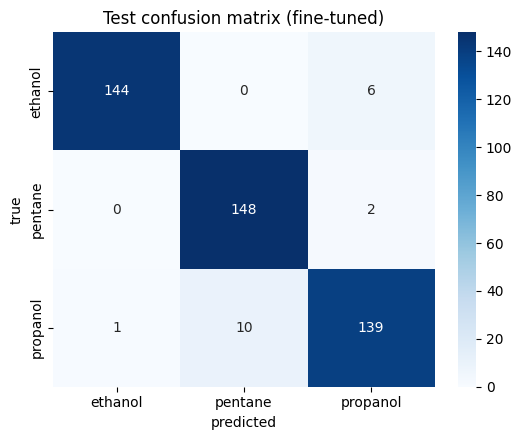

saved /scratch/faculty/hkim/quanhao/EE541/HW9/hw9_confusion_matrix.png


In [7]:
@torch.no_grad()
def collect_predictions(m: nn.Module, loader: DataLoader):
    m.eval()
    ys, ps, probs = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = m(xb)
        pr = torch.softmax(logits, dim=1).cpu().numpy()
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(pred)
        probs.append(pr)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    y_score = np.vstack(probs)
    return y_true, y_pred, y_score


y_true, y_pred, y_score = collect_predictions(model_ft, test_loader)
cm = confusion_matrix(y_true, y_pred)
print("confusion_matrix (rows=true, cols=pred):\n", cm)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Test confusion matrix (fine-tuned)")
plt.tight_layout()
p_cm = HW9_ROOT / "hw9_confusion_matrix.png"
plt.savefig(p_cm, dpi=160)
plt.show()
print("saved", p_cm)


## 7. One-vs-rest precision–recall (sklearn)

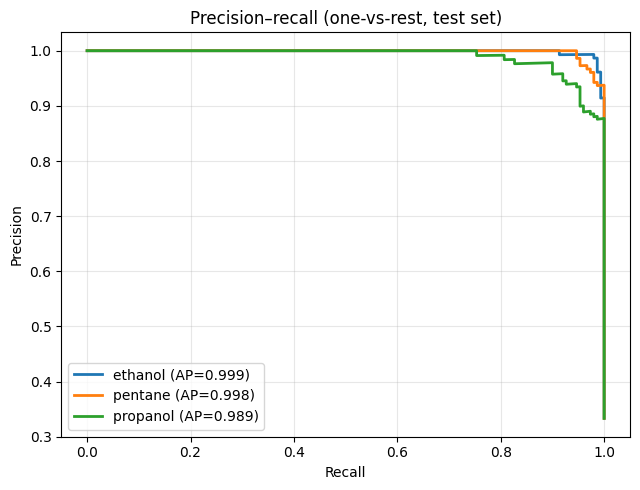

saved /scratch/faculty/hkim/quanhao/EE541/HW9/hw9_precision_recall.png
per-class AP: {'ethanol': 0.9986191785710911, 'pentane': 0.9978485869357301, 'propanol': 0.9894033946798191}


In [8]:
classes = np.arange(len(class_names))
Y = label_binarize(y_true, classes=classes)

plt.figure(figsize=(6.5, 5))
ap_list = []
for i, name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(Y[:, i], y_score[:, i])
    ap = average_precision_score(Y[:, i], y_score[:, i])
    ap_list.append(ap)
    plt.plot(recall, precision, lw=2, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–recall (one-vs-rest, test set)")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left")
plt.tight_layout()
p_pr = HW9_ROOT / "hw9_precision_recall.png"
plt.savefig(p_pr, dpi=160)
plt.show()
print("saved", p_pr)
print("per-class AP:", dict(zip(class_names, ap_list)))


## 8. Feature-map visualization

Forward **hooks** on **`conv1`**, a **mid-network** block (**`layer2[0].conv1`**), and deeper **`layer3[0].conv1`**. `torchvision.utils.make_grid` builds grayscale grids (first 32 channels) for one validation batch image.

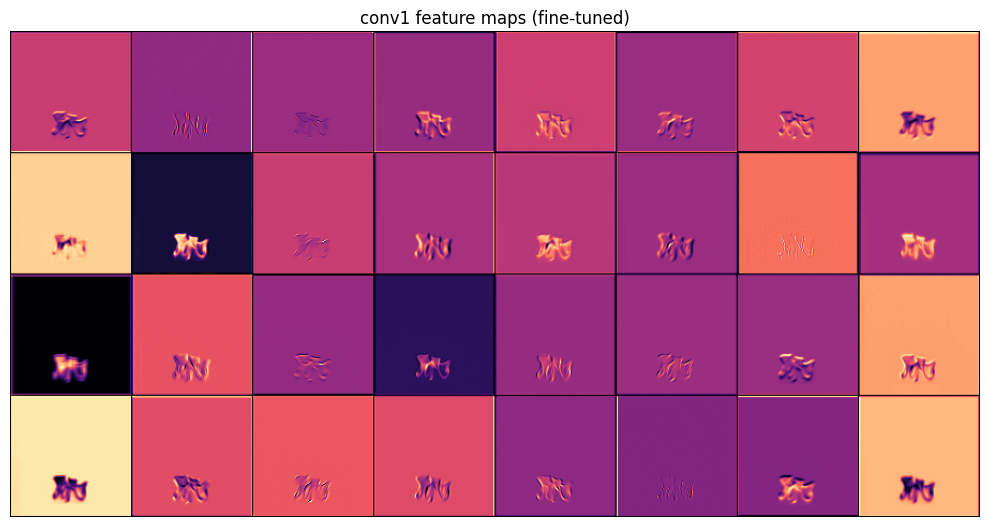

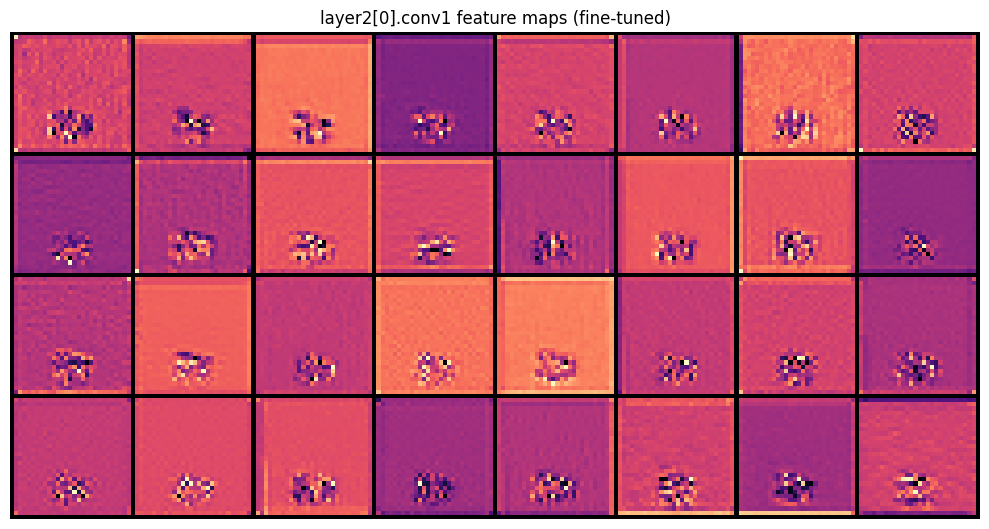

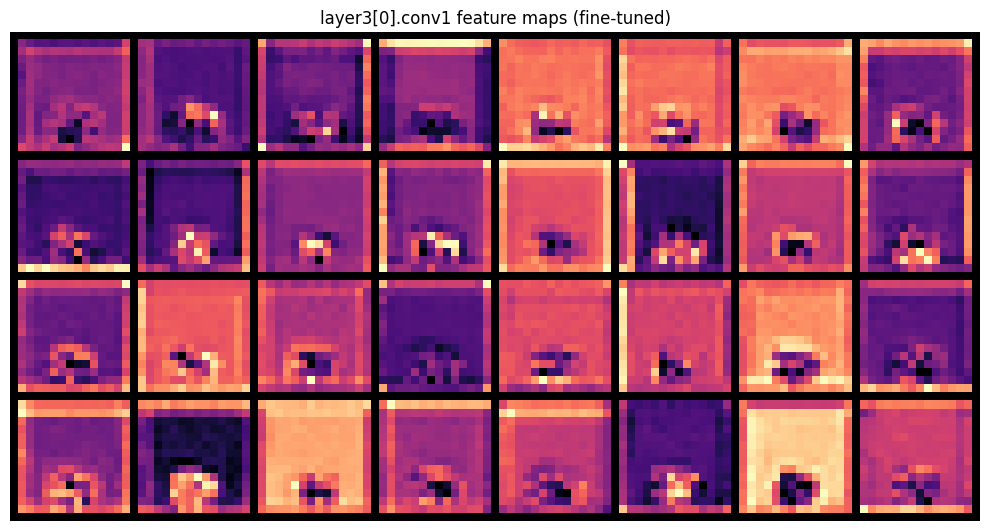

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.3889, 0.3112,  ..., 0.7921, 0.9665, 0.0000],
         [0.0000, 0.4511, 0.5668,  ..., 0.6208, 0.7116, 0.0000],
         ...,
         [0.0000, 0.6692, 0.5730,  ..., 0.4017, 0.3970, 0.0000],
         [0.0000, 0.7802, 0.7283,  ..., 0.7792, 0.6422, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.3889, 0.3112,  ..., 0.7921, 0.9665, 0.0000],
         [0.0000, 0.4511, 0.5668,  ..., 0.6208, 0.7116, 0.0000],
         ...,
         [0.0000, 0.6692, 0.5730,  ..., 0.4017, 0.3970, 0.0000],
         [0.0000, 0.7802, 0.7283,  ..., 0.7792, 0.6422, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.3889, 0.3112,  ..., 0.7921, 0.9665, 0.0000],
         [0.0000, 0.4511, 0.5668,  ..., 0.6208, 0.7116, 0.

In [ ]:
def _to_grid(feature_map: torch.Tensor, nrow: int = 8, max_ch: int = 32) -> torch.Tensor:
    # feature_map: (1, C, H, W)
    t = feature_map[0, :max_ch].detach().float().cpu()
    t = t.unsqueeze(1)  # (N,1,H,W)
    t = t - t.amin(dim=(2, 3), keepdim=True)
    den = t.amax(dim=(2, 3), keepdim=True).clamp_min(1e-6)
    t = t / den
    return make_grid(t, nrow=nrow, padding=1)


@torch.no_grad()
def show_layer_grid(
    m: nn.Module,
    x: torch.Tensor,
    layer: nn.Module,
    title: str,
    save_path: Path,
):
    acts = {}

    def hook(_mod, _inp, out):
        acts["out"] = out

    h = layer.register_forward_hook(hook)
    try:
        m.eval()
        _ = m(x)
    finally:
        h.remove()
    grid = _to_grid(acts["out"])
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).numpy()[:, :, 0], cmap="magma")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.show()
    return grid

xb0, yb0 = next(iter(val_loader))
x_single = xb0[:1].to(device)

show_layer_grid(
    model_ft,
    x_single,
    model_ft.conv1,
    "conv1 feature maps (fine-tuned)",
    HW9_ROOT / "hw9_features_conv1.png",
)
show_layer_grid(
    model_ft,
    x_single,
    model_ft.layer2[0].conv1,
    "layer2[0].conv1 feature maps (fine-tuned)",
    HW9_ROOT / "hw9_features_layer2b0_conv1.png",
)
show_layer_grid(
    model_ft,
    x_single,
    model_ft.layer3[0].conv1,
    "layer3[0].conv1 feature maps (fine-tuned)",
    HW9_ROOT / "hw9_features_layer3b0_conv1.png",
)


## 9. Short analysis

- Staged unfreezing limits early destructive updates to ImageNet filters while the new `fc` adapts.
- The **baseline** is **vanilla pretrained ResNet-34** with a **fresh three-class `fc` and zero training steps** (random head on ImageNet features) — expected accuracy **≈1/3** on balanced three-way data — vs. **fine-tuned** test accuracy.
- Confusion matrix and PR curves summarize which liquids are confused when errors occur.